# Visual Ingredient Scanner — YOLO11s Training on Google Colab


This notebook:
1. Downloads all 4 Roboflow datasets
2. Merges them into one dataset, applying all class renames automatically
3. Trains YOLO11s for 50 epochs
4. Evaluates mAP and plots training curves
5. Exports to TFLite INT8 + CoreML
6. Saves everything to Google Drive

### Before running
1. Set runtime to **T4 GPU**: `Runtime → Change runtime type → T4 GPU`
2. Add your Roboflow API key as a Colab secret (🔑 icon → `ROBOFLOW_API_KEY`)
3. Fill in the workspace slugs in **Cell 4** (the `YOUR_WORKSPACE` placeholders)
4. Run all cells top to bottom

## 1 · Install dependencies

In [ ]:
!pip install -q ultralytics roboflow pyyaml
print("Done.")

Done.


## 2 · Verify GPU

In [35]:
!nvidia-smi
import torch
assert torch.cuda.is_available(), "No GPU — change runtime to T4 GPU"
print(f"GPU: {torch.cuda.get_device_name(0)}")

Wed May 27 16:45:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   61C    P0             30W /   70W |    5553MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 3 · Mount Google Drive

In [12]:
import os
DRIVE_DIR = "/content/outputs"
os.makedirs(DRIVE_DIR, exist_ok=True)
print("Output folder ready — files will download directly to your computer at the end.")

Output folder ready — files will download directly to your computer at the end.


## 4 · Dataset configuration

Fill in the `YOUR_WORKSPACE` placeholders with the workspace slugs from the Roboflow URLs.  
The workspace slug is the part after `universe.roboflow.com/` in the dataset URL.

Also check the **version numbers** — open each dataset on Roboflow and look at the version tab.

In [17]:
from google.colab import userdata

ROBOFLOW_API_KEY = userdata.get("ROBOFLOW_API_KEY")

# ── Your merged dataset ───────────────────────────────────────────────────
WORKSPACE = "emma-w8nkb"   # ← fill in
PROJECT   = "visual-ingredient-scanner"     # ← fill in
VERSION   = 1                  # ← check version number on Roboflow

# ── Master class list — 68 classes ───────────────────────────────────────
MASTER_CLASSES = [
    "apple","avocado","banana","blackberries","blueberries","cantaloupe",
    "coconut","fig","grapes","grapefruit","kiwi","lemon","lime","mango",
    "orange","peach","pear","pineapple","pomegranate","raspberries",
    "strawberries","watermelon",
    "artichoke","beet","broccoli","brussels_sprouts","cabbage","carrot",
    "cauliflower","celery","chili","corn","cucumber","eggplant","garlic",
    "ginger","green_beans","lettuce","mushrooms","okra","onion","peas",
    "pepper","potato","pumpkin","radish","spinach","sweet_potato","tomato",
    "zucchini",
    "beef","butter","cheese","chicken","egg","fish","ham","heavy_cream",
    "pork","shrimp","tofu","yogurt",
    "bread","cereal","chocolate","coffee","flour","honey","hummus","jam",
    "juice","mayonnaise","milk","nuts","oil","pasta","rice","soda",
    "sugar","tea","tomato_sauce","vinegar","water",
]
MASTER_IDX = {name: i for i, name in enumerate(MASTER_CLASSES)}

# ── Combined rename map (applied after lowercasing) ───────────────────────
RENAME_MAP = {
    "mayonaise":         "mayonnaise",
    "humus":             "hummus",
    "green beans":       "green_beans",
    "goat_cheese":       "cheese",
    "mozzarella cheese": "cheese",
    "olive_oil":         "oil",
    "bell pepper":       "pepper",
    "salad":             "lettuce",
    "common fig":        "fig",
    "vegetable marrow":  "zucchini",
    "brus capusta":      "brussels_sprouts",
    "cayliflower":       "cauliflower",
    "rediska":           "radish",
    "redka":             "radish",
    "fasol":             "beans",
    "chilli":            "chili",
    "hot pepper":        "chili",
}

# ── Classes to discard entirely ───────────────────────────────────────────
SKIP_SET = {
    "bittergourd", "chayote", "meat",
    "winter melon",
    "banana_pacche", "squash-patisson", "burger",
    "cake", "candy", "chips", "spices",
}

print(f"Master classes: {len(MASTER_CLASSES)}")

Master classes: 83


## 5 · Download all datasets from Roboflow

In [19]:
from roboflow import Roboflow
from pathlib import Path
import yaml

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
dataset = rf.workspace(WORKSPACE).project(PROJECT).version(VERSION).download(
    "yolov11", location="/content/datasets/raw"
)
RAW_DIR = dataset.location
print(f"Downloaded to: {RAW_DIR}")

# Preview classes in the downloaded dataset
data_cfg = yaml.safe_load(Path(RAW_DIR, "data.yaml").read_text())
print(f"Classes in dataset ({data_cfg['nc']}): {data_cfg['names']}")

loading Roboflow workspace...
loading Roboflow project...
Exporting format yolov11 in progress : 95.0%
Version export complete for yolov11 format



Extracting Dataset Version Zip to /content/datasets/raw in yolov11:: 100%|██████████| 149257/149257 [00:24<00:00, 6205.01it/s] 


Downloaded to: /content/datasets/raw
Classes in dataset (121): ['Apple', 'Artichoke', 'Avocado', 'Banana', 'Bell Pepper', 'Bell pepper', 'Broccoli', 'Burger', 'Cabbage', 'Cantaloupe', 'Carrot', 'Coconut', 'Common fig', 'Cucumber', 'Grape', 'Grapefruit', 'Lemon', 'Lettuce', 'Mango', 'Orange', 'Peach', 'Pear', 'Pineapple', 'Pomegranate', 'Potato', 'Pumpkin', 'Radish', 'Salad', 'Strawberry', 'Tomato', 'Watermelon', 'Winter melon', 'apple', 'avocado', 'banana', 'banana_pacche', 'beans', 'beef', 'beet', 'bittergourd', 'blackberries', 'blueberries', 'bread', 'broccoli', 'brus capusta', 'butter', 'cabbage', 'cake', 'candy', 'carrot', 'cayliflower', 'celery', 'cereal', 'chayote', 'cheese', 'chicken', 'chilli', 'chips', 'chocolate', 'coffee', 'corn', 'cucumber', 'egg', 'eggplant', 'fasol', 'fish', 'flour', 'garlic', 'ginger', 'goat_cheese', 'grapes', 'green beans', 'ground beef', 'ham', 'heavy cream', 'honey', 'hot pepper', 'humus', 'jam', 'juice', 'kiwi', 'lemon', 'lettuce', 'lime', 'mayonaise

## 6 · Merge datasets with class remapping

For each dataset:
- Lowercases all class names
- Applies the rename map
- Skips excluded classes
- Remaps class indices in every label file to match the master list
- Copies images + remapped labels into a unified directory

In [21]:
import shutil

MERGED_DIR = Path("/content/datasets/merged")

def build_remap(source_names, rename_map, skip_set):
    """Return dict: source_idx -> master_idx, or -1 to discard."""
    remap = {}
    for i, name in enumerate(source_names):
        norm = name.lower().strip()
        if norm in skip_set:
            remap[i] = -1
            continue
        norm = rename_map.get(norm, norm)
        remap[i] = MASTER_IDX.get(norm, -1)  # -1 if not in master list
    return remap

def remap_label(src, dst, remap):
    """Rewrite a YOLO .txt label file with remapped class indices."""
    lines_out = []
    for line in Path(src).read_text().strip().splitlines():
        if not line.strip():
            continue
        parts = line.split()
        master_idx = remap.get(int(parts[0]), -1)
        if master_idx >= 0:
            lines_out.append(f"{master_idx} " + " ".join(parts[1:]))
    Path(dst).write_text("\n".join(lines_out))

def merge_split(src_dir, split, remap, prefix):
    img_src = Path(src_dir) / split / "images"
    lbl_src = Path(src_dir) / split / "labels"
    img_dst = MERGED_DIR / split / "images"
    lbl_dst = MERGED_DIR / split / "labels"
    img_dst.mkdir(parents=True, exist_ok=True)
    lbl_dst.mkdir(parents=True, exist_ok=True)

    if not img_src.exists():
        return 0

    count = 0
    for img_path in img_src.iterdir():
        # prefix filename to avoid collisions between datasets
        new_stem = f"ds{prefix}_{img_path.stem}"
        shutil.copy(img_path, img_dst / (new_stem + img_path.suffix))
        lbl_path = lbl_src / (img_path.stem + ".txt")
        if lbl_path.exists():
            remap_label(lbl_path, lbl_dst / (new_stem + ".txt"), remap)
        count += 1
    return count

# ── Run merge ────────────────────────────────────────────────────────────────
total = {"train": 0, "valid": 0, "test": 0}

data_yaml = yaml.safe_load(Path(RAW_DIR, "data.yaml").read_text())
source_names = data_yaml["names"]
remap = build_remap(source_names, RENAME_MAP, SKIP_SET)

kept    = sum(1 for v in remap.values() if v >= 0)
skipped = sum(1 for v in remap.values() if v < 0)
print(f"Source classes : {len(source_names)}")
print(f"Kept           : {kept}")
print(f"Skipped        : {skipped}")

for split in ("train", "valid", "test"):
    total[split] = merge_split(RAW_DIR, split, remap, 0)

merged_yaml = {
    "path":  str(MERGED_DIR),
    "train": "train/images",
    "val":   "valid/images",
    "test":  "test/images",
    "nc":    len(MASTER_CLASSES),
    "names": MASTER_CLASSES,
}
MERGED_YAML = str(MERGED_DIR / "data.yaml")
with open(MERGED_YAML, "w") as f:
    yaml.dump(merged_yaml, f, default_flow_style=False, sort_keys=False)

print("=" * 50)
print(f"Merged dataset: {MERGED_DIR}")
print(f"  train : {total['train']} images")
print(f"  valid : {total['valid']} images")
print(f"  test  : {total['test']} images")
print(f"  total : {sum(total.values())} images")
print(f"  classes: {len(MASTER_CLASSES)}")

Source classes : 121
Kept           : 104
Skipped        : 17
Merged dataset: /content/datasets/merged
  train : 69209 images
  valid : 2841 images
  test  : 2576 images
  total : 74626 images
  classes: 83


## 7 · Verify merged dataset

Classes with data: 82 / 83
Classes with NO training data: ['heavy_cream']


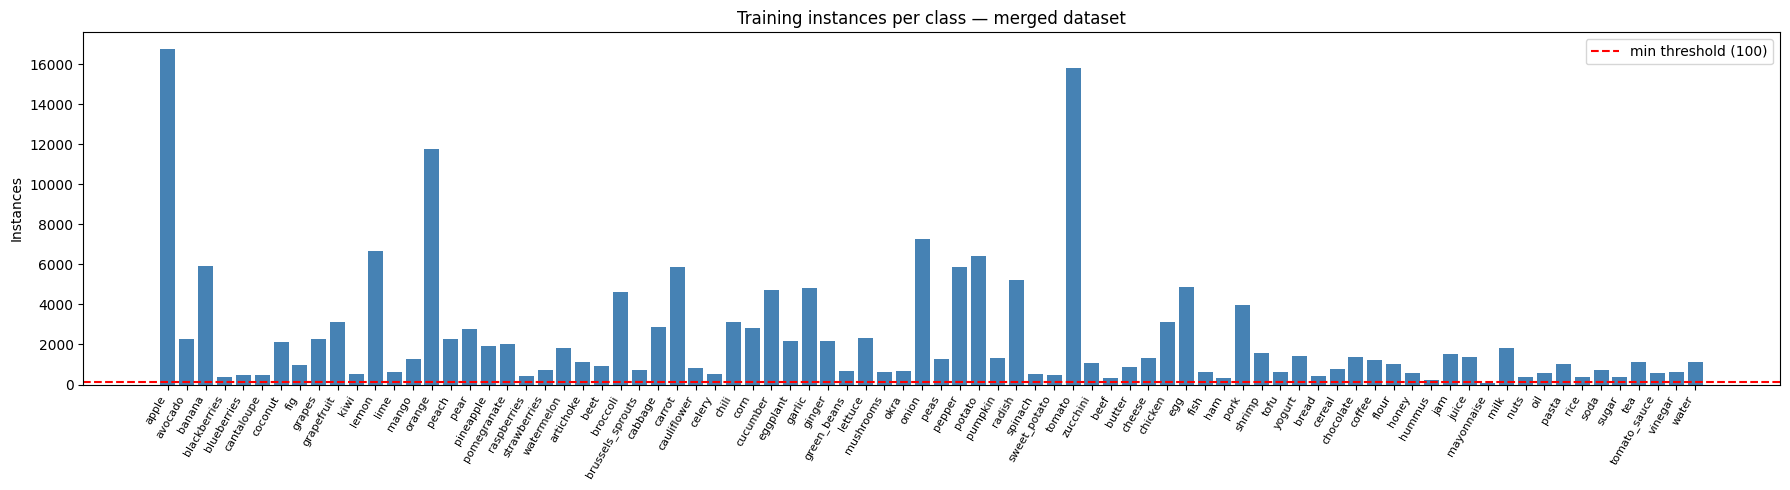

In [22]:
from collections import Counter
import matplotlib.pyplot as plt

# Count instances per class in training set
counter = Counter()
label_dir = MERGED_DIR / "train" / "labels"
for lf in label_dir.glob("*.txt"):
    for line in lf.read_text().strip().splitlines():
        if line:
            counter[int(line.split()[0])] += 1

labels  = [MASTER_CLASSES[i] for i in sorted(counter)]
counts  = [counter[i] for i in sorted(counter)]
missing = [c for c in MASTER_CLASSES if MASTER_IDX[c] not in counter]

print(f"Classes with data: {len(counter)} / {len(MASTER_CLASSES)}")
if missing:
    print(f"Classes with NO training data: {missing}")

fig, ax = plt.subplots(figsize=(18, 5))
ax.bar(labels, counts, color="steelblue")
ax.axhline(100, color="red", linestyle="--", label="min threshold (100)")
ax.set_title("Training instances per class — merged dataset")
ax.set_ylabel("Instances")
ax.legend()
plt.xticks(rotation=60, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

In [31]:
print(f"\n{'Class':<25} {'Instances':>10}")
print("-" * 37)
for i in sorted(counter, key=lambda x: counter[x], reverse=True):
    print(f"{MASTER_CLASSES[i]:<25} {counter[i]:>10}")

if missing:
    print(f"\nMissing (0 instances):")
    for c in missing:
        print(f"  {c}")


Class                      Instances
-------------------------------------
coconut                         2000
banana                          2000
corn                            2000
carrot                          2000
chili                           2000
lettuce                         2000
cabbage                         1999
onion                           1999
grapes                          1999
eggplant                        1999
avocado                         1998
chicken                         1998
pear                            1997
broccoli                        1983
pomegranate                     1962
orange                          1952
radish                          1926
lemon                           1924
pork                            1856
tomato                          1855
apple                           1842
cucumber                        1836
garlic                          1827
peach                           1819
pineapple                       1816

In [29]:
import random
from collections import defaultdict, Counter
from pathlib import Path

MAX_INSTANCES = 2000
label_dir = MERGED_DIR / "train" / "labels"
img_dir   = MERGED_DIR / "train" / "images"

# Build a map: file -> {cls: instance_count}
file_instances = {}
for lf in label_dir.glob("*.txt"):
    content = lf.read_text().strip()
    if not content:
        continue
    counts = Counter(
        int(line.split()[0])
        for line in content.splitlines() if line
    )
    file_instances[lf] = counts

# For each class, list (file, instance_count_in_file)
class_data = defaultdict(list)
for lf, counts in file_instances.items():
    for cls, cnt in counts.items():
        class_data[cls].append((lf, cnt))

# Print over-represented classes before capping
print(f"{'Class':<25} {'Instances':>10}")
print("-" * 37)
for cls in sorted(class_data,
                  key=lambda c: sum(cnt for _, cnt in class_data[c]),
                  reverse=True):
    total = sum(cnt for _, cnt in class_data[c])
    if total > MAX_INSTANCES:
        solo  = sum(1 for lf, _ in class_data[c] if len(file_instances[lf]) == 1)
        mixed = sum(1 for lf, _ in class_data[c] if len(file_instances[lf]) > 1)
        print(f"{MASTER_CLASSES[cls]:<25} {total:>10}  (solo files: {solo}, mixed files: {mixed})")

# ── Cap each class by instance count ─────────────────────────────────────────
removed_files = set()

for cls in sorted(class_data,
                  key=lambda c: sum(cnt for _, cnt in class_data[c]),
                  reverse=True):

    available = [(lf, cnt) for lf, cnt in class_data[cls]
                 if lf not in removed_files]
    total_instances = sum(cnt for _, cnt in available)

    if total_instances <= MAX_INSTANCES:
        continue

    instances_to_remove = total_instances - MAX_INSTANCES

    # Separate solo (no collateral) vs mixed (affects other classes)
    solo_items  = [(lf, cnt) for lf, cnt in available
                   if len(file_instances[lf]) == 1]
    mixed_items = [(lf, cnt) for lf, cnt in available
                   if len(file_instances[lf]) > 1]

    random.shuffle(solo_items)
    random.shuffle(mixed_items)

    # Step 1 — delete solo files first
    for lf, cnt in solo_items:
        if instances_to_remove <= 0:
            break
        removed_files.add(lf)
        instances_to_remove -= cnt

    # Step 2 — delete mixed files only if still needed
    if instances_to_remove > 0:
        for lf, cnt in mixed_items:
            if instances_to_remove <= 0:
                break
            removed_files.add(lf)
            instances_to_remove -= cnt

    removed_count = sum(
        cnt for lf, cnt in available if lf in removed_files
    )
    print(f"{MASTER_CLASSES[cls]:<25} {total_instances} → ~{total_instances - removed_count}")

# ── Physically delete files ───────────────────────────────────────────────────
for lf in removed_files:
    for ext in (".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"):
        img = img_dir / (lf.stem + ext)
        if img.exists():
            img.unlink()
            break
    lf.unlink(missing_ok=True)

print(f"\nDeleted {len(removed_files)} files.")
print("Re-run Cell 7 to verify the new distribution.")


Class                      Instances
-------------------------------------
orange                    11085 → ~1994
apple                     4919 → ~1997
egg                       4660 → ~1997
cucumber                  4341 → ~1959
radish                    4449 → ~2000
tomato                    3959 → ~2000
lemon                     3113 → ~2000
broccoli                  3363 → ~2000
garlic                    3066 → ~2000
pork                      2892 → ~1993
onion                     2350 → ~1999
carrot                    2863 → ~2000
chili                     3053 → ~2000
banana                    2573 → ~2000
cabbage                   2587 → ~1999
chicken                   2387 → ~1998
pear                      2676 → ~1997
corn                      2512 → ~2000
avocado                   2239 → ~1998
grapes                    2249 → ~1999
lettuce                   2127 → ~2000
coconut                   2115 → ~2000

Deleted 10769 files.
Re-run Cell 7 to verify the new distribution

Classes with data: 82 / 83
Classes with NO training data: ['heavy_cream']


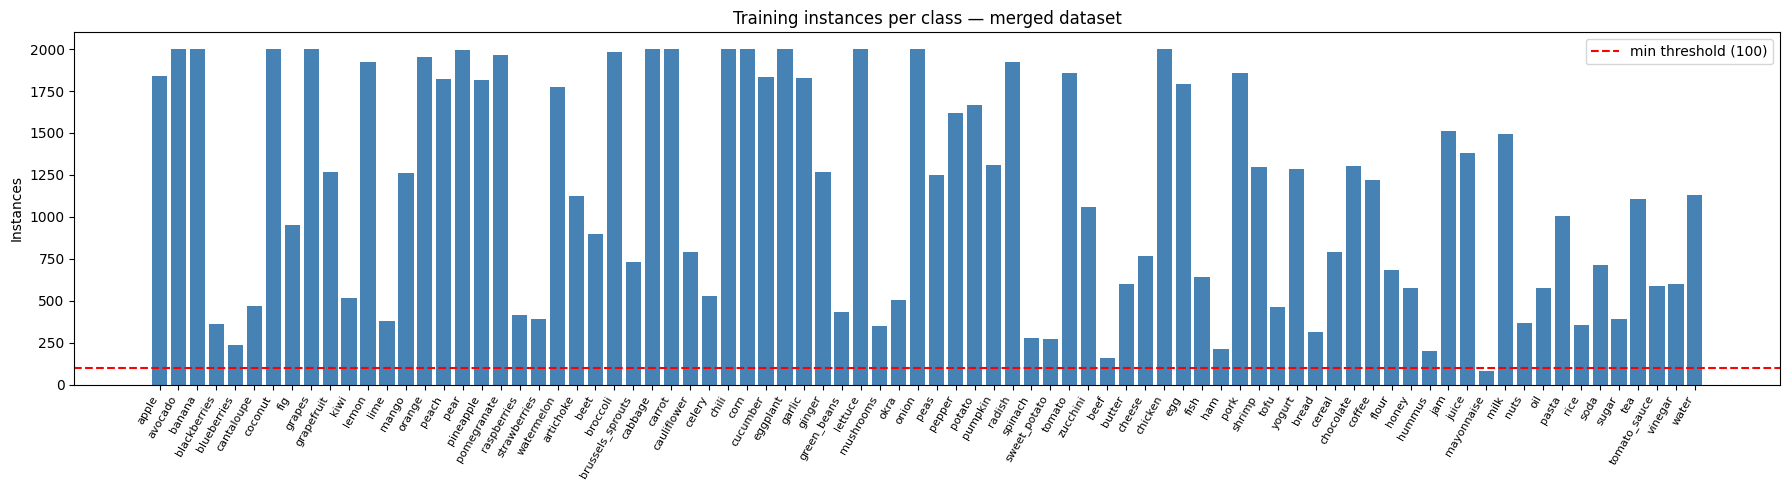

In [37]:
# Count instances per class in training set
counter = Counter()
label_dir = MERGED_DIR / "train" / "labels"
for lf in label_dir.glob("*.txt"):
    for line in lf.read_text().strip().splitlines():
        if line:
            counter[int(line.split()[0])] += 1

labels  = [MASTER_CLASSES[i] for i in sorted(counter)]
counts  = [counter[i] for i in sorted(counter)]
missing = [c for c in MASTER_CLASSES if MASTER_IDX[c] not in counter]

print(f"Classes with data: {len(counter)} / {len(MASTER_CLASSES)}")
if missing:
    print(f"Classes with NO training data: {missing}")

fig, ax = plt.subplots(figsize=(18, 5))
ax.bar(labels, counts, color="steelblue")
ax.axhline(100, color="red", linestyle="--", label="min threshold (100)")
ax.set_title("Training instances per class — merged dataset")
ax.set_ylabel("Instances")
ax.legend()
plt.xticks(rotation=60, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

## 8 · Train YOLO11s

Expected time on T4: **~1–2 hours** depending on total image count.

In [38]:
from pathlib import Path
label_dir = MERGED_DIR / "train" / "labels"
print(sum(1 for _ in label_dir.glob("*.txt")))

41266


In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11s.pt")  # downloads base checkpoint automatically
'''
results = model.train(
    data=MERGED_YAML,
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    cos_lr=True,
    augment=True,
    project="runs/train",
    name="food_detector",
    exist_ok=True,
)
'''

results = model.train(
    data=MERGED_YAML,
    epochs=25,
    imgsz=416,
    batch=16,
    cos_lr=True,
    augment=True,
    cache=True,      # ← loads dataset into RAM, eliminates disk bottleneck
    workers=4,       # ← parallel data loading threads
    project="/content/runs",
    name="food_detector",
)

BEST_PT = "runs/train/food_detector/weights/best.pt"
print(f"\nBest checkpoint: {BEST_PT}")

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/datasets/merged/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=food_detector-4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pati

In [6]:

from google.colab import drive
drive.mount("/content/drive")

ValueError: mount failed

In [5]:
!ls /content/runs/


ls: cannot access '/content/runs/': No such file or directory


## 9 · Evaluate — preliminary metrics

Target: **mAP50-95 > 0.40**

In [2]:
trained = YOLO(BEST_PT)
metrics = trained.val(data=MERGED_YAML, split="test", device=0)

print(f"\nmAP50-95 : {metrics.box.map:.3f}  (target > 0.40)")
print(f"mAP50    : {metrics.box.map50:.3f}")
print(f"mAP75    : {metrics.box.map75:.3f}")
print()
print("Per-class mAP50-95:")
for name, ap in zip(metrics.names.values(), metrics.box.maps):
    flag = "✅" if ap >= 0.40 else "⚠️ "
    print(f"  {flag} {name:<22} {ap:.3f}")

NameError: name 'YOLO' is not defined

## 10 · Plot training curves

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("runs/train/food_detector/results.csv")
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(df["epoch"], df["train/box_loss"], label="train")
axes[0].plot(df["epoch"], df["val/box_loss"],   label="val")
axes[0].set_title("Box loss"); axes[0].legend()

axes[1].plot(df["epoch"], df["train/cls_loss"], label="train")
axes[1].plot(df["epoch"], df["val/cls_loss"],   label="val")
axes[1].set_title("Class loss"); axes[1].legend()

axes[2].plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
axes[2].plot(df["epoch"], df["metrics/mAP50(B)"],    label="mAP50")
axes[2].axhline(0.40, color="red", linestyle="--", label="target 0.40")
axes[2].set_title("mAP"); axes[2].legend()

plt.suptitle("Training curves — YOLO11s food detector")
plt.tight_layout()
plt.savefig(f"{DRIVE_DIR}/training_curves.png", dpi=150)
plt.show()
print("Saved training_curves.png to Drive")

## 11 · Export to TFLite (Android) and CoreML (iOS)

In [ ]:
trained.export(format="tflite", int8=True, imgsz=640, data=MERGED_YAML)
print("TFLite INT8 export done.")

In [ ]:
try:
    trained.export(format="coreml", imgsz=640)
    print("CoreML export done.")
except Exception as e:
    print(f"CoreML skipped (needs macOS): {e}")

## 12 · Save all outputs

In [ ]:
from google.colab import files
from pathlib import Path

weights_dir = Path("runs/train/food_detector/weights")

print("Starting downloads to your computer...")

for name, path in [
    ("food_detector.pt",          weights_dir / "best.pt"),
    ("food_detector_last.pt",     weights_dir / "last.pt"),
    ("results.csv",               Path("runs/train/food_detector/results.csv")),
]:
    if path.exists():
        files.download(str(path))
        print(f"  ↓ {name}")

for tflite in weights_dir.glob("*.tflite"):
    files.download(str(tflite))
    print(f"  ↓ {tflite.name}")

print("\nCheck your browser Downloads folder.")

## 13 · Quick inference test

In [ ]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image as PILImage

val_img_dir = MERGED_DIR / "valid" / "images"
test_imgs = random.sample(sorted(val_img_dir.glob("*")), min(4, len(list(val_img_dir.glob("*")))))

fig, axes = plt.subplots(1, len(test_imgs), figsize=(16, 5))
if len(test_imgs) == 1:
    axes = [axes]

for ax, img_path in zip(axes, test_imgs):
    preds = trained(str(img_path), conf=0.25, verbose=False)[0]
    img = PILImage.open(img_path)
    ax.imshow(img)
    for box in preds.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        cls  = preds.names[int(box.cls)]
        conf = float(box.conf)
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                   linewidth=2, edgecolor="lime", facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, y1-5, f"{cls} {conf:.2f}", color="lime", fontsize=8)
    ax.axis("off")

plt.suptitle("Inference on validation images", fontsize=14)
plt.tight_layout()
plt.savefig(f"{DRIVE_DIR}/inference_samples.png", dpi=150)
plt.show()
print("Saved inference_samples.png to Drive")

## Summary

After running this notebook you should have in `MyDrive/visual-ingredient-scanner/`:

| File | Description |
|---|---|
| `food_detector.pt` | Fine-tuned YOLO11s checkpoint |
| `food_detector_last.pt` | Last epoch checkpoint (backup) |
| `food_detector_int8.tflite` | INT8 TFLite export for Android |
| `results.csv` | Per-epoch training metrics |
| `training_curves.png` | Loss + mAP plots |
| `inference_samples.png` | Sample detection results |
| `merged_data.yaml` | Merged dataset config (for re-running eval) |

### Next steps
1. Download `food_detector.pt` → place at `models/yolo/food_detector.pt` in the repo
2. Download `food_detector_int8.tflite` → place at `models/yolo/food_detector.tflite`
3. Create `.env` with `GEMINI_API_KEY=your_key`
4. Run the Gradio demo: `python prototype/app.py`
5. Add the mAP number to `docs/phase2_report.md` Section 6